# 🔬 Skin Lesion Classifier v3 — Segmentation-Guided Classification
### HAM10000 · 7-Class · Swin-B Encoder + Mask-Guided FPN + SE Block

**What is new in v4 (the research contribution):**
- ✅ **Segmentation-Guided Feature Extraction** — SwinUNet v4 mask suppresses background noise
- ✅ **Squeeze-and-Excitation (SE) Block** — learns which FPN dimensions matter most per image
- ✅ **Sqrt WeightedRandomSampler** — fixes v2 NV collapse while still helping rare classes
- ✅ MixUp alpha=0.4, prob=0.3 (calibrated from v2)
- ✅ Phase 2 extended to 50 epochs

## STEP 1 — Check GPU

In [1]:
import torch
print(f'PyTorch version : {torch.__version__}')
print(f'CUDA available  : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU             : {torch.cuda.get_device_name(0)}')
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device    : {DEVICE}')

PyTorch version : 2.5.1+cu121
CUDA available  : True
GPU             : NVIDIA GeForce RTX 3060
Using device    : cuda


## STEP 2 — Install Dependencies

In [2]:
!pip install -q timm albumentations scikit-learn grad-cam lime
print('Done.')

Done.


## STEP 3 — Imports

In [4]:
import os, random, warnings
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

try:
    from torch.amp import GradScaler, autocast
except ImportError:
    from torch.cuda.amp import GradScaler, autocast

import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2
from tqdm import tqdm
from PIL import Image
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
print(f'albumentations : {A.__version__}')
print(f'timm           : {timm.__version__}')

albumentations : 2.0.8
timm           : 1.0.22


## STEP 4 — Configuration

> **Edit only the paths block below. Everything else is auto-configured.**

In [5]:
# ── Edit only these paths ─────────────────────────────────────────────────────
IMAGE_DIR        = r'D:\MULTIMODAL CLASSIFICATION V4\data\classification\images'
MASK_DIR         = r'D:\MULTIMODAL CLASSIFICATION V4\data\classification\mask'
METADATA_CSV     = r'D:\MULTIMODAL CLASSIFICATION V4\metadata\HAM10000_metadata.csv'
ENCODER_WEIGHTS  = r'D:\MULTIMODAL CLASSIFICATION V4\models\swinunet_v4_encoder.pth'
SWINUNET_WEIGHTS = r'D:\MULTIMODAL CLASSIFICATION V4\models\swinunet_v4_best.pth'
SAVE_DIR         = r'D:\MULTIMODAL CLASSIFICATION V4\outputs\classifier_v4'
# ──────────────────────────────────────────────────────────────────────────────

IMG_SIZE        = 224
BATCH_SIZE      = 32
NUM_WORKERS     = 0
PIN_MEMORY      = (DEVICE == 'cuda')

PHASE1_EPOCHS   = 10
PHASE1_LR       = 1e-3
PHASE2_EPOCHS   = 50
PHASE2_LR       = 1e-5
WEIGHT_DECAY    = 1e-4
PATIENCE        = 10
LABEL_SMOOTHING = 0.1

MIXUP_ALPHA     = 0.4
MIXUP_PROB      = 0.3

# How strongly the mask suppresses background features.
# 1.0 = full hard masking (background zeroed).
# 0.7 = soft masking (background reduced to 30%). Safer for imperfect masks.
MASK_ALPHA      = 0.7

TRAIN_RATIO, VAL_RATIO, TEST_RATIO = 0.70, 0.15, 0.15

CLASS_NAMES  = ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
CLASS_LABELS = {name: idx for idx, name in enumerate(CLASS_NAMES)}
NUM_CLASSES  = len(CLASS_NAMES)

os.makedirs(SAVE_DIR, exist_ok=True)
MODEL_SAVE_PATH = os.path.join(SAVE_DIR, 'skin_classifier_v4_best.pth')
REPORT_PATH     = os.path.join(SAVE_DIR, 'classification_report.txt')
CONF_MAT_PATH   = os.path.join(SAVE_DIR, 'confusion_matrix.png')
CURVE_PATH      = os.path.join(SAVE_DIR, 'training_curves.png')
XAI_DIR         = os.path.join(SAVE_DIR, 'xai_outputs')
os.makedirs(XAI_DIR, exist_ok=True)

print(f'Device        : {DEVICE}')
print(f'Image size    : {IMG_SIZE}x{IMG_SIZE}')
print(f'Batch size    : {BATCH_SIZE}')
print(f'Classes ({NUM_CLASSES})   : {CLASS_NAMES}')
print(f'Phase 1       : {PHASE1_EPOCHS} epochs, LR={PHASE1_LR}')
print(f'Phase 2       : {PHASE2_EPOCHS} epochs, LR={PHASE2_LR}')
print(f'MixUp         : alpha={MIXUP_ALPHA}, prob={MIXUP_PROB}')
print(f'Mask guidance : alpha={MASK_ALPHA}')
print(f'Save dir      : {SAVE_DIR}')

Device        : cuda
Image size    : 224x224
Batch size    : 32
Classes (7)   : ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
Phase 1       : 10 epochs, LR=0.001
Phase 2       : 50 epochs, LR=1e-05
MixUp         : alpha=0.4, prob=0.3
Mask guidance : alpha=0.7
Save dir      : D:\MULTIMODAL CLASSIFICATION V4\outputs\classifier_v4


## STEP 5 — Load Metadata & Compute Class Weights

In [6]:
df = pd.read_csv(METADATA_CSV)

def image_exists(image_id):
    for ext in ['.jpg', '.jpeg', '.png']:
        if os.path.exists(os.path.join(IMAGE_DIR, image_id + ext)):
            return True
    return False

df = df[df['image_id'].apply(image_exists)].reset_index(drop=True)
df['label'] = df['dx'].map(CLASS_LABELS)
df = df.dropna(subset=['label'])
df['label'] = df['label'].astype(int)

print(f'Total valid samples: {len(df)}')
print('\nClass distribution:')
for cls in CLASS_NAMES:
    count = (df['dx'] == cls).sum()
    pct   = 100 * count / len(df)
    bar   = '█' * int(pct / 2)
    print(f'  {cls:6s}: {count:5d}  ({pct:5.1f}%)  {bar}')

class_counts         = np.array([(df['label'] == i).sum() for i in range(NUM_CLASSES)], dtype=np.float32)
class_weights        = 1.0 / (class_counts + 1e-6)
class_weights        = class_weights / class_weights.sum() * NUM_CLASSES
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)

print('\nClass weights (for loss):')
for cls, w in zip(CLASS_NAMES, class_weights):
    print(f'  {cls:6s}: {w:.4f}')

Total valid samples: 10015

Class distribution:
  akiec :   327  (  3.3%)  █
  bcc   :   514  (  5.1%)  ██
  bkl   :  1099  ( 11.0%)  █████
  df    :   115  (  1.1%)  
  mel   :  1113  ( 11.1%)  █████
  nv    :  6705  ( 66.9%)  █████████████████████████████████
  vasc  :   142  (  1.4%)  

Class weights (for loss):
  akiec : 0.9431
  bcc   : 0.6000
  bkl   : 0.2806
  df    : 2.6816
  mel   : 0.2771
  nv    : 0.0460
  vasc  : 2.1717


## STEP 6 — Train / Val / Test Split

In [7]:
train_df, tmp_df = train_test_split(
    df, test_size=(VAL_RATIO + TEST_RATIO),
    stratify=df['label'], random_state=42
)
val_df, test_df = train_test_split(
    tmp_df, test_size=TEST_RATIO / (VAL_RATIO + TEST_RATIO),
    stratify=tmp_df['label'], random_state=42
)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)
print(f'Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}')

Train: 7010 | Val: 1502 | Test: 1503


## STEP 7 — Dataset & DataLoader

**Key changes from v3:**
- Dataset now loads the segmentation mask alongside the image
- Mask is passed through the same spatial transforms as the image (flip, rotate, etc.)
- Sqrt WeightedRandomSampler — DF:NV ratio reduced from 58x to ~7.6x

In [8]:
def find_mask_path(image_id, mask_dir):
    """Find the HAM10000 segmentation mask for a given image_id.
    HAM10000 mask filenames follow the pattern: ISIC_XXXXXXX_segmentation.png
    Falls back to any matching file if the standard pattern is not found.
    """
    for suffix in [f'_segmentation.png', f'_segmentation.jpg', '.png', '.jpg']:
        p = os.path.join(mask_dir, image_id + suffix)
        if os.path.exists(p):
            return p
    return None


class HAMDatasetWithMask(Dataset):
    """
    Loads image + segmentation mask pairs.
    If a mask is not found for a sample, a full-ones mask is used
    (equivalent to no masking for that sample).
    """
    def __init__(self, dataframe, image_dir, mask_dir, transform=None):
        self.df        = dataframe
        self.image_dir = image_dir
        self.mask_dir  = mask_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def _find_image(self, image_id):
        for ext in ['.jpg', '.jpeg', '.png']:
            p = os.path.join(self.image_dir, image_id + ext)
            if os.path.exists(p):
                return p
        raise FileNotFoundError(f'Image not found: {image_id}')

    def __getitem__(self, idx):
        row      = self.df.iloc[idx]
        img_path = self._find_image(row['image_id'])
        image    = np.array(Image.open(img_path).convert('RGB'))
        label    = int(row['label'])

        # Load mask — use all-ones (no masking) if mask file not found
        mask_path = find_mask_path(row['image_id'], self.mask_dir)
        if mask_path is not None:
            mask = np.array(Image.open(mask_path).convert('L'), dtype=np.float32)
            mask = (mask > 127).astype(np.float32)   # binarize
        else:
            mask = np.ones((image.shape[0], image.shape[1]), dtype=np.float32)

        if self.transform:
            aug   = self.transform(image=image, mask=mask)
            image = aug['image']
            mask  = aug['mask']       # (H, W) float tensor after ToTensorV2
        else:
            image = torch.from_numpy(image.transpose(2, 0, 1)).float()
            mask  = torch.from_numpy(mask).float()

        # Ensure mask is (1, H, W)
        if mask.dim() == 2:
            mask = mask.unsqueeze(0)

        return image, mask, label


_albu_ver = tuple(int(x) for x in A.__version__.split('.')[:2])
if _albu_ver >= (1, 4):
    _coarse  = A.CoarseDropout(num_holes_range=(1, 4), hole_height_range=(16, 32),
                                hole_width_range=(16, 32), p=0.2)
    _elastic = A.ElasticTransform(p=0.2)
else:
    _coarse  = A.CoarseDropout(max_holes=4, max_height=32, max_width=32, p=0.2)
    _elastic = A.ElasticTransform(alpha=120, sigma=120 * 0.05, p=0.2)

# Note: mask=True in additional_targets ensures mask gets the same spatial transforms
train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.Rotate(limit=30, p=0.4),
    _elastic,
    A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=0.4),
    A.CLAHE(clip_limit=2.0, p=0.3),
    A.GaussianBlur(blur_limit=(3, 5), p=0.2),
    _coarse,
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
], additional_targets={'mask': 'mask'})

eval_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
], additional_targets={'mask': 'mask'})

train_dataset = HAMDatasetWithMask(train_df, IMAGE_DIR, MASK_DIR, train_transform)
val_dataset   = HAMDatasetWithMask(val_df,   IMAGE_DIR, MASK_DIR, eval_transform)
test_dataset  = HAMDatasetWithMask(test_df,  IMAGE_DIR, MASK_DIR, eval_transform)

# ── Sqrt WeightedRandomSampler (v4 fix) ──────────────────────────────────────
# sqrt inverse-frequency: DF:NV ratio = ~7.6x (was 58x in v2/v3 — caused NV collapse)
train_labels       = train_df['label'].values
train_class_counts = np.bincount(train_labels, minlength=NUM_CLASSES).astype(np.float32)
sample_weights     = 1.0 / np.sqrt(train_class_counts[train_labels])   # ← SQRT fix
sampler            = WeightedRandomSampler(
    weights     = torch.from_numpy(sample_weights).float(),
    num_samples = len(train_dataset),
    replacement = True
)

print('Sqrt class sample weights for sampler:')
sqrt_w = 1.0 / np.sqrt(train_class_counts)
max_w  = sqrt_w.max()
for cls, cnt, w in zip(CLASS_NAMES, train_class_counts, sqrt_w):
    bar = '█' * int(w / max_w * 20)
    print(f'  {cls:6s}: {int(cnt):4d} samples → weight {w:.5f}  {bar}')

print(f'\n  DF:NV sampling ratio: {sqrt_w[3]/sqrt_w[5]:.1f}x  (was 58x in v2/v3)')

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          sampler=sampler,
                          num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

print(f'\nTrain batches: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}')
print('Sqrt WeightedRandomSampler active ✅')

Sqrt class sample weights for sampler:
  akiec :  229 samples → weight 0.06608  ███████████
  bcc   :  360 samples → weight 0.05270  █████████
  bkl   :  769 samples → weight 0.03606  ██████
  df    :   81 samples → weight 0.11111  ████████████████████
  mel   :  779 samples → weight 0.03583  ██████
  nv    : 4693 samples → weight 0.01460  ██
  vasc  :   99 samples → weight 0.10050  ██████████████████

  DF:NV sampling ratio: 7.6x  (was 58x in v2/v3)

Train batches: 220 | Val: 47 | Test: 47
Sqrt WeightedRandomSampler active ✅


## STEP 8 — Model Architecture

```
Input Image 224x224x3
       │
       ├──► SwinUNet v4 (frozen) ──► Soft Lesion Mask (224x224)
       │                                      │
       └──► Swin-B Encoder                    │ downsampled to each stage
              │  e0: 128ch, 56x56  ────× mask ─┤
              │  e1: 256ch, 28x28  ────× mask ─┤
              │  e2: 512ch, 14x14  ────× mask ─┤
              │  e3:1024ch,  7x7   ────× mask ─┘
              │
              └──► FPN (top-down fusion) ──► P0-P3 each 256ch
                          │
                          └──► GAP each → 256d → Concat → 1024d
                                          │
                                     SE Block (channel attention)
                                          │
                                     MLP: 1024→512→256→7 logits
```

In [9]:
# ── Squeeze-and-Excitation Block ─────────────────────────────────────────────
class SEBlock(nn.Module):
    """
    Squeeze-and-Excitation block.
    Learns to re-weight each of the 1024 feature dimensions based on
    their global context — lets the model say 'for this image, fine-texture
    features matter more than coarse-semantic ones' (or vice versa).
    reduction=16 means the bottleneck is 1024/16 = 64 dimensions.
    """
    def __init__(self, dim, reduction=16):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(dim, dim // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(dim // reduction, dim, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        # x: (B, dim)
        # SE learns a per-channel scale factor in [0,1]
        scale = self.fc(x)
        return x * scale


# ── Feature Pyramid Network ───────────────────────────────────────────────────
class FPN(nn.Module):
    def __init__(self, in_channels_list, out_channels=256):
        super().__init__()
        self.lateral_convs = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(in_ch, out_channels, kernel_size=1, bias=False),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True)
            )
            for in_ch in in_channels_list
        ])
        self.smooth_convs = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True)
            )
            for _ in in_channels_list
        ])
        self.out_channels = out_channels

    def forward(self, features):
        laterals = [conv(f) for conv, f in zip(self.lateral_convs, features)]
        for i in range(len(laterals) - 1, 0, -1):
            upsampled = F.interpolate(
                laterals[i], size=laterals[i - 1].shape[2:],
                mode='bilinear', align_corners=False
            )
            laterals[i - 1] = laterals[i - 1] + upsampled
        return [smooth(lat) for smooth, lat in zip(self.smooth_convs, laterals)]


# ── Main Classifier ───────────────────────────────────────────────────────────
class SkinLesionClassifierV4(nn.Module):
    """
    v4 additions over v3:
      1. mask_guided_forward(): applies segmentation mask to encoder features
         before FPN, forcing the classifier to focus on lesion-internal features
      2. SEBlock after FPN concatenation: learns per-dimension feature importance
    """
    def __init__(self, num_classes=7, fpn_out=256, dropout=0.4,
                 pretrained_encoder=None, mask_alpha=0.7):
        super().__init__()
        self.mask_alpha = mask_alpha   # soft masking strength

        # ── Encoder ─────────────────────────────────────────────────────────
        self.encoder = timm.create_model(
            'swin_base_patch4_window7_224',
            pretrained=False,
            features_only=True,
            out_indices=(0, 1, 2, 3)
        )

        if pretrained_encoder is not None:
            ckpt      = torch.load(pretrained_encoder, map_location='cpu', weights_only=False)
            enc_state = ckpt.get('encoder_state_dict', ckpt)
            missing, unexpected = self.encoder.load_state_dict(enc_state, strict=False)
            print(f'  Encoder loaded. Missing: {len(missing)} | Unexpected: {len(unexpected)}')
        else:
            print('  No encoder weights — randomly initialised.')

        with torch.no_grad():
            _d = torch.zeros(1, 3, IMG_SIZE, IMG_SIZE)
            _f = self.encoder(_d)
            enc_channels = [self._to_spatial(f).shape[1] for f in _f]
        print(f'  Encoder channels: {enc_channels}')
        self.enc_channels = enc_channels

        # ── FPN ─────────────────────────────────────────────────────────────
        self.fpn = FPN(enc_channels, out_channels=fpn_out)

        # ── SE Block (NEW in v4) ─────────────────────────────────────────────
        concat_dim = 4 * fpn_out   # 1024
        self.se    = SEBlock(concat_dim, reduction=16)

        # ── MLP Head ─────────────────────────────────────────────────────────
        self.classifier = nn.Sequential(
            nn.Linear(concat_dim, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout * 0.75),
            nn.Linear(256, num_classes)
        )
        self._init_head()

    def _init_head(self):
        for m in self.classifier.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    @staticmethod
    def _to_spatial(x):
        if x.dim() == 4 and x.shape[-1] > x.shape[1]:
            return x.permute(0, 3, 1, 2).contiguous()
        if x.dim() == 3:
            B, L, C = x.shape
            H = W = int(L ** 0.5)
            return x.reshape(B, H, W, C).permute(0, 3, 1, 2).contiguous()
        return x

    def _apply_mask(self, feat, mask):
        """
        Apply soft segmentation mask to a spatial feature map.
        feat : (B, C, H, W)
        mask : (B, 1, H_orig, W_orig)  — resized to match feat spatial dims

        Soft masking formula:
            masked_feat = feat * (mask_alpha * mask + (1 - mask_alpha))
        When mask=1 (lesion): weight = mask_alpha + (1-mask_alpha) = 1.0  → full
        When mask=0 (background): weight = (1-mask_alpha)                 → dampened
        """
        mask_resized = F.interpolate(
            mask, size=feat.shape[2:], mode='bilinear', align_corners=False
        )
        weight = self.mask_alpha * mask_resized + (1.0 - self.mask_alpha)
        return feat * weight

    def freeze_encoder(self):
        for p in self.encoder.parameters():
            p.requires_grad = False
        print('  ✅ Encoder FROZEN')

    def unfreeze_encoder(self):
        for p in self.encoder.parameters():
            p.requires_grad = True
        print('  ✅ Encoder UNFROZEN (fine-tuning)')

    def trainable_params(self):
        n     = sum(p.numel() for p in self.parameters() if p.requires_grad)
        total = sum(p.numel() for p in self.parameters())
        print(f'  Trainable: {n/1e6:.1f}M / {total/1e6:.1f}M')

    def forward(self, x, mask=None):
        """
        x    : (B, 3, 224, 224)  — normalized image
        mask : (B, 1, 224, 224)  — soft lesion mask in [0,1]
                                    If None, no mask guidance applied (fallback)
        """
        # Extract encoder features
        enc_feats = [self._to_spatial(f) for f in self.encoder(x)]

        # Apply mask guidance to each encoder stage (NEW in v4)
        if mask is not None:
            enc_feats = [self._apply_mask(f, mask) for f in enc_feats]

        # FPN fusion
        pyramid = self.fpn(enc_feats)

        # Global average pool each FPN level → 256d, concat → 1024d
        pooled = [F.adaptive_avg_pool2d(p, 1).flatten(1) for p in pyramid]
        feat   = torch.cat(pooled, dim=1)   # (B, 1024)

        # SE channel attention (NEW in v4)
        feat = self.se(feat)

        # MLP head → logits
        return self.classifier(feat)


print('Building SkinLesionClassifierV4...')
model = SkinLesionClassifierV4(
    num_classes=NUM_CLASSES,
    fpn_out=256,
    dropout=0.4,
    pretrained_encoder=ENCODER_WEIGHTS,
    mask_alpha=MASK_ALPHA
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
print(f'\nModel ready | {total_params/1e6:.1f}M total parameters')

# Shape check (with mask)
with torch.no_grad():
    _img  = torch.zeros(2, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
    _mask = torch.ones(2, 1, IMG_SIZE, IMG_SIZE).to(DEVICE)
    _out  = model(_img, _mask)
    print(f'Output shape (with mask): {_out.shape}  ✅')
    _out2 = model(_img, None)
    print(f'Output shape (no mask)  : {_out2.shape}  ✅')

Building SkinLesionClassifierV4...
  Encoder loaded. Missing: 0 | Unexpected: 0
  Encoder channels: [128, 256, 512, 1024]

Model ready | 90.4M total parameters
Output shape (with mask): torch.Size([2, 7])  ✅
Output shape (no mask)  : torch.Size([2, 7])  ✅


## STEP 9 — Loss Function

In [10]:
criterion = nn.CrossEntropyLoss(
    weight=class_weights_tensor,
    label_smoothing=LABEL_SMOOTHING
)
print(f'Loss : WeightedCrossEntropyLoss (label_smoothing={LABEL_SMOOTHING})')
print(f'Class weights: {[f"{w:.3f}" for w in class_weights]}')

Loss : WeightedCrossEntropyLoss (label_smoothing=0.1)
Class weights: ['0.943', '0.600', '0.281', '2.682', '0.277', '0.046', '2.172']


## STEP 10 — Training & Evaluation Utilities (MixUp-aware, mask-aware)

In [11]:
def mixup_data(images, masks, labels, alpha=MIXUP_ALPHA, device=DEVICE):
    """MixUp applied to both images AND their masks simultaneously."""
    lam          = np.random.beta(alpha, alpha) if alpha > 0 else 1.0
    index        = torch.randperm(images.size(0), device=device)
    mixed_images = lam * images + (1 - lam) * images[index]
    mixed_masks  = lam * masks  + (1 - lam) * masks[index]
    return mixed_images, mixed_masks, labels, labels[index], lam


def mixup_criterion(criterion, logits, label_a, label_b, lam):
    return lam * criterion(logits, label_a) + (1 - lam) * criterion(logits, label_b)


def train_one_epoch(model, loader, optimizer, criterion, scaler, device, use_mixup=True):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    pbar = tqdm(loader, desc='  Train', leave=False)

    for imgs, masks, labels in pbar:
        imgs, masks, labels = imgs.to(device), masks.to(device), labels.to(device)
        optimizer.zero_grad()

        apply_mixup = use_mixup and (random.random() < MIXUP_PROB)

        with autocast(device_type=device):
            if apply_mixup:
                mixed_imgs, mixed_masks, label_a, label_b, lam = mixup_data(
                    imgs, masks, labels, device=device
                )
                logits = model(mixed_imgs, mixed_masks)
                loss   = mixup_criterion(criterion, logits, label_a, label_b, lam)
            else:
                logits = model(imgs, masks)
                loss   = criterion(logits, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item() * imgs.size(0)
        preds       = logits.argmax(dim=1)
        ref_labels  = labels if not apply_mixup else (label_a if lam >= 0.5 else label_b)
        correct    += (preds == ref_labels).sum().item()
        total      += imgs.size(0)
        pbar.set_postfix(loss=f'{loss.item():.4f}', acc=f'{correct/total:.4f}')

    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []

    for imgs, masks, labels in tqdm(loader, desc='  Eval ', leave=False):
        imgs, masks, labels = imgs.to(device), masks.to(device), labels.to(device)
        with autocast(device_type=device):
            logits = model(imgs, masks)
            loss   = criterion(logits, labels)
        total_loss += loss.item() * imgs.size(0)
        preds       = logits.argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += imgs.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    return (total_loss / total, correct / total,
            f1_score(all_labels, all_preds, average='macro', zero_division=0),
            all_preds, all_labels)


def save_curves(history, path):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, key, title in zip(axes, ['loss', 'acc', 'macro_f1'],
                               ['Loss', 'Accuracy', 'Macro F1']):
        ax.plot(history['train_' + key], label='Train')
        ax.plot(history['val_'   + key], label='Val')
        ax.set_title(title); ax.set_xlabel('Epoch')
        ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.close()
    print(f'  Curves saved → {path}')


def save_confusion_matrix(y_true, y_pred, class_names, path):
    cm      = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    fig, ax = plt.subplots(figsize=(9, 7))
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_title('Normalised Confusion Matrix')
    plt.tight_layout()
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.close()
    print(f'  Confusion matrix saved → {path}')


print(f'Utilities ready. MixUp: alpha={MIXUP_ALPHA}, prob={MIXUP_PROB}')

Utilities ready. MixUp: alpha=0.4, prob=0.3


## STEP 11 — Phase 1 Training: Frozen Encoder

Only the FPN, SE block, and MLP head are trained (3.5M parameters).
Encoder stays frozen so we don't destroy the segmentation-pretrained features.

In [12]:
print('=' * 60)
print('  PHASE 1 — Frozen encoder | Mask-Guided | SE | Sqrt-Sampler | MixUp')
print('=' * 60)

model.freeze_encoder()
model.trainable_params()

optimizer_p1 = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=PHASE1_LR, weight_decay=WEIGHT_DECAY
)
scheduler_p1 = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_p1, T_max=PHASE1_EPOCHS, eta_min=PHASE1_LR * 0.1
)
scaler = GradScaler()

history = {
    'train_loss': [], 'val_loss': [],
    'train_acc':  [], 'val_acc':  [],
    'train_macro_f1': [], 'val_macro_f1': []
}
best_val_f1  = 0.0
patience_ctr = 0

for epoch in range(1, PHASE1_EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch(
        model, train_loader, optimizer_p1, criterion, scaler, DEVICE, use_mixup=True
    )
    vl_loss, vl_acc, vl_f1, _, _ = evaluate(model, val_loader,   criterion, DEVICE)
    _,       tr_acc, tr_f1, _, _ = evaluate(model, train_loader, criterion, DEVICE)

    history['train_loss'].append(tr_loss);    history['val_loss'].append(vl_loss)
    history['train_acc'].append(tr_acc);      history['val_acc'].append(vl_acc)
    history['train_macro_f1'].append(tr_f1);  history['val_macro_f1'].append(vl_f1)
    scheduler_p1.step()

    improved = vl_f1 > best_val_f1
    if improved:
        best_val_f1  = vl_f1
        patience_ctr = 0
        torch.save({'model_state_dict': model.state_dict(),
                    'epoch': epoch, 'phase': 1,
                    'best_val_f1': best_val_f1}, MODEL_SAVE_PATH)
    else:
        patience_ctr += 1

    flag = '✅' if improved else '  '
    print(f'  {flag} Ep {epoch:02d}/{PHASE1_EPOCHS} '
          f'| TrLoss {tr_loss:.4f} TrAcc {tr_acc:.4f} TrF1 {tr_f1:.4f} '
          f'| VlLoss {vl_loss:.4f} VlAcc {vl_acc:.4f} VlF1 {vl_f1:.4f}')

    if patience_ctr >= PATIENCE:
        print(f'  Early stopping at epoch {epoch}')
        break

print(f'\nPhase 1 complete. Best Val Macro-F1: {best_val_f1:.4f}')
save_curves(history, CURVE_PATH.replace('.png', '_phase1.png'))

  PHASE 1 — Frozen encoder | Mask-Guided | SE | Sqrt-Sampler | MixUp
  ✅ Encoder FROZEN
  Trainable: 3.6M / 90.4M


  ✅ Ep 01/10 | TrLoss 1.3873 TrAcc 0.4997 TrF1 0.5279 | VlLoss 1.9924 VlAcc 0.3628 VlF1 0.4078


  ✅ Ep 02/10 | TrLoss 1.1606 TrAcc 0.5820 TrF1 0.6172 | VlLoss 1.9024 VlAcc 0.4328 VlF1 0.4518


     Ep 03/10 | TrLoss 1.0551 TrAcc 0.4890 TrF1 0.5680 | VlLoss 1.9843 VlAcc 0.2390 VlF1 0.4188


  ✅ Ep 04/10 | TrLoss 1.0267 TrAcc 0.6077 TrF1 0.6515 | VlLoss 1.8419 VlAcc 0.4461 VlF1 0.5049


...

  ✅ Ep 06/10 | TrLoss 0.9941 TrAcc 0.7103 TrF1 0.7304 | VlLoss 1.7936 VlAcc 0.5699 VlF1 0.5244


  ✅ Ep 07/10 | TrLoss 0.9477 TrAcc 0.7335 TrF1 0.7641 | VlLoss 1.7977 VlAcc 0.5766 VlF1 0.5550


  ✅ Ep 08/10 | TrLoss 0.8878 TrAcc 0.7914 TrF1 0.8198 | VlLoss 1.7784 VlAcc 0.6658 VlF1 0.6189


     Ep 09/10 | TrLoss 0.9038 TrAcc 0.7438 TrF1 0.7797 | VlLoss 1.7556 VlAcc 0.5866 VlF1 0.6005


     Ep 10/10 | TrLoss 0.9113 TrAcc 0.7381 TrF1 0.7776 | VlLoss 1.7726 VlAcc 0.5866 VlF1 0.5814

Phase 1 complete. Best Val Macro-F1: 0.6189
  Curves saved → D:\MULTIMODAL CLASSIFICATION V4\outputs\classifier_v4\training_curves_phase1.png


## STEP 12 — Phase 2 Training: Full Fine-Tune

Loads best Phase 1 checkpoint, unfreezes encoder.
Differential LR: encoder=1e-5, head/FPN/SE=5e-5.

In [13]:
print('=' * 60)
print('  PHASE 2 — Full fine-tune | 50 epochs | Mask-Guided | SE')
print('=' * 60)

ckpt = torch.load(MODEL_SAVE_PATH, map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt['model_state_dict'])
print(f'  Loaded Phase 1 best (epoch {ckpt["epoch"]}, Val F1={ckpt["best_val_f1"]:.4f})')

model.unfreeze_encoder()
model.trainable_params()

encoder_params     = list(model.encoder.parameters())
non_encoder_params = [p for p in model.parameters()
                      if not any(p is ep for ep in encoder_params)]

optimizer_p2 = torch.optim.AdamW([
    {'params': encoder_params,     'lr': PHASE2_LR},
    {'params': non_encoder_params, 'lr': PHASE2_LR * 5}
], weight_decay=WEIGHT_DECAY)

scheduler_p2 = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_p2, T_max=PHASE2_EPOCHS, eta_min=PHASE2_LR * 0.1
)

history2 = {
    'train_loss': [], 'val_loss': [],
    'train_acc':  [], 'val_acc':  [],
    'train_macro_f1': [], 'val_macro_f1': []
}
best_val_f1_p2 = ckpt['best_val_f1']
patience_ctr   = 0

for epoch in range(1, PHASE2_EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch(
        model, train_loader, optimizer_p2, criterion, scaler, DEVICE, use_mixup=True
    )
    vl_loss, vl_acc, vl_f1, _, _ = evaluate(model, val_loader,   criterion, DEVICE)
    _,       tr_acc, tr_f1, _, _ = evaluate(model, train_loader, criterion, DEVICE)

    history2['train_loss'].append(tr_loss);    history2['val_loss'].append(vl_loss)
    history2['train_acc'].append(tr_acc);      history2['val_acc'].append(vl_acc)
    history2['train_macro_f1'].append(tr_f1);  history2['val_macro_f1'].append(vl_f1)
    scheduler_p2.step()

    improved = vl_f1 > best_val_f1_p2
    if improved:
        best_val_f1_p2 = vl_f1
        patience_ctr   = 0
        torch.save({'model_state_dict': model.state_dict(),
                    'epoch': epoch, 'phase': 2,
                    'best_val_f1': best_val_f1_p2}, MODEL_SAVE_PATH)
    else:
        patience_ctr += 1

    flag = '✅' if improved else '  '
    print(f'  {flag} Ep {epoch:02d}/{PHASE2_EPOCHS} '
          f'| TrLoss {tr_loss:.4f} TrAcc {tr_acc:.4f} TrF1 {tr_f1:.4f} '
          f'| VlLoss {vl_loss:.4f} VlAcc {vl_acc:.4f} VlF1 {vl_f1:.4f}')

    if patience_ctr >= PATIENCE:
        print(f'  Early stopping triggered at epoch {epoch}.')
        break

print(f'\nPhase 2 complete. Best Val Macro-F1: {best_val_f1_p2:.4f}')
save_curves(history2, CURVE_PATH.replace('.png', '_phase2.png'))

  PHASE 2 — Full fine-tune | 50 epochs | Mask-Guided | SE
  Loaded Phase 1 best (epoch 8, Val F1=0.6189)
  ✅ Encoder UNFROZEN (fine-tuning)
  Trainable: 90.4M / 90.4M


     Ep 01/50 | TrLoss 0.8904 TrAcc 0.7716 TrF1 0.8029 | VlLoss 1.7396 VlAcc 0.6431 VlF1 0.6076


  ✅ Ep 02/50 | TrLoss 0.9077 TrAcc 0.8375 TrF1 0.8509 | VlLoss 1.7376 VlAcc 0.7383 VlF1 0.6566


     Ep 03/50 | TrLoss 0.9078 TrAcc 0.7873 TrF1 0.8235 | VlLoss 1.7619 VlAcc 0.6551 VlF1 0.6298


     Ep 04/50 | TrLoss 0.8882 TrAcc 0.8254 TrF1 0.8414 | VlLoss 1.7273 VlAcc 0.6917 VlF1 0.6239


...

     Ep 33/50 | TrLoss 0.7596 TrAcc 0.9672 TrF1 0.9628 | VlLoss 1.6467 VlAcc 0.8742 VlF1 0.7726


     Ep 34/50 | TrLoss 0.8106 TrAcc 0.9670 TrF1 0.9613 | VlLoss 1.6458 VlAcc 0.8589 VlF1 0.7608


     Ep 35/50 | TrLoss 0.7669 TrAcc 0.9643 TrF1 0.9609 | VlLoss 1.6507 VlAcc 0.8702 VlF1 0.7624


     Ep 36/50 | TrLoss 0.7859 TrAcc 0.9728 TrF1 0.9705 | VlLoss 1.6526 VlAcc 0.8702 VlF1 0.7550


     Ep 37/50 | TrLoss 0.7594 TrAcc 0.9738 TrF1 0.9699 | VlLoss 1.6523 VlAcc 0.8815 VlF1 0.7700
  Early stopping triggered at epoch 37.

Phase 2 complete. Best Val Macro-F1: 0.7784
  Curves saved → D:\MULTIMODAL CLASSIFICATION V4\outputs\classifier_v4\training_curves_phase2.png


## STEP 13 — Test Set Evaluation

In [14]:
ckpt = torch.load(MODEL_SAVE_PATH, map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt['model_state_dict'])
print(f'Loaded best: phase {ckpt["phase"]}, epoch {ckpt["epoch"]}, Val F1={ckpt["best_val_f1"]:.4f}')

test_loss, test_acc, test_f1, test_preds, test_labels = evaluate(
    model, test_loader, criterion, DEVICE
)

print('\n' + '=' * 57)
print('  TEST RESULTS — v4 (Mask-Guided + SE + Sqrt Sampler)')
print('=' * 57)
print(f'  Loss      : {test_loss:.4f}')
print(f'  Accuracy  : {test_acc:.4f}  ({test_acc*100:.1f}%)')
print(f'  Macro F1  : {test_f1:.4f}')
print('=' * 57)

report = classification_report(test_labels, test_preds, target_names=CLASS_NAMES, digits=4)
print('\nPer-class report:')
print(report)

with open(REPORT_PATH, 'w') as f:
    f.write(f'Model         : SkinLesionClassifier v4\n')
    f.write(f'Architecture  : Swin-B + Mask-Guided FPN + SE Block\n')
    f.write(f'Test Loss     : {test_loss:.4f}\n')
    f.write(f'Test Accuracy : {test_acc:.4f}\n')
    f.write(f'Test Macro F1 : {test_f1:.4f}\n\n')
    f.write(report)
print(f'Report saved → {REPORT_PATH}')

Loaded best: phase 2, epoch 27, Val F1=0.7784



  TEST RESULTS — v4 (Mask-Guided + SE + Sqrt Sampler)
  Loss      : 1.6644
  Accuracy  : 0.8709  (87.1%)
  Macro F1  : 0.7587

Per-class report:
              precision    recall  f1-score   support

       akiec     0.7647    0.7959    0.7800        49
         bcc     0.8642    0.9091    0.8861        77
         bkl     0.8609    0.7879    0.8228       165
          df     0.2381    0.8824    0.3750        17
         mel     0.6699    0.8383    0.7447       167
          nv     0.9781    0.8877    0.9307      1006
        vasc     0.6286    1.0000    0.7719        22

    accuracy                         0.8709      1503
   macro avg     0.7149    0.8716    0.7587      1503
weighted avg     0.9047    0.8709    0.8824      1503

Report saved → D:\MULTIMODAL CLASSIFICATION V4\outputs\classifier_v4\classification_report.txt


## STEP 14 — Confusion Matrix

  Confusion matrix saved → D:\MULTIMODAL CLASSIFICATION V4\outputs\classifier_v4\confusion_matrix.png


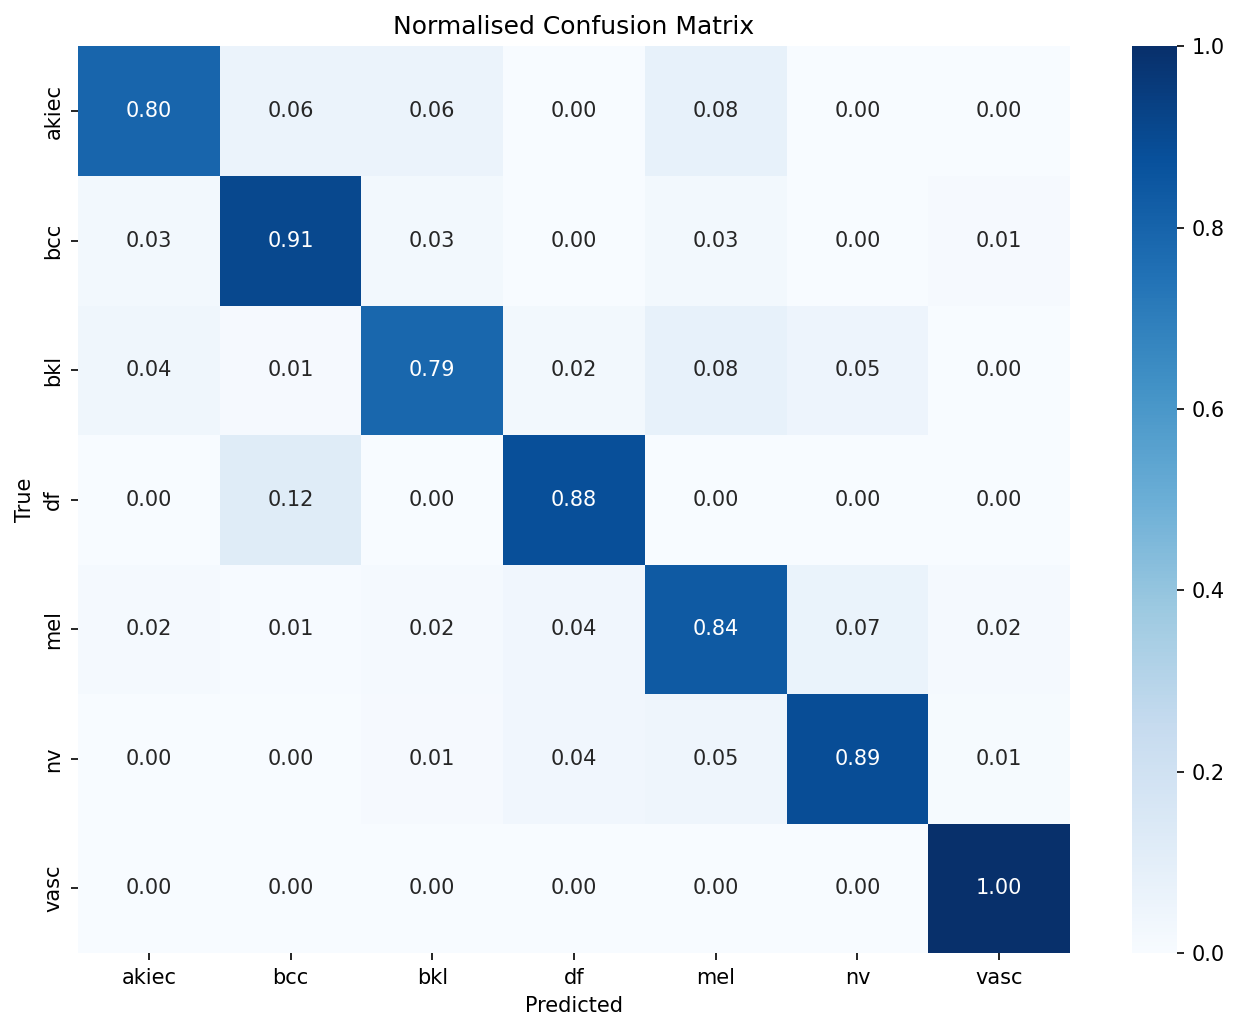

In [15]:
save_confusion_matrix(test_labels, test_preds, CLASS_NAMES, CONF_MAT_PATH)
try:
    from IPython.display import Image as IPImage, display
    display(IPImage(CONF_MAT_PATH))
except Exception:
    print(f'Open manually: {CONF_MAT_PATH}')

## STEP 15 — Per-Class Accuracy Bar Chart

Bar chart saved → D:\MULTIMODAL CLASSIFICATION V4\outputs\classifier_v4\per_class_acc.png


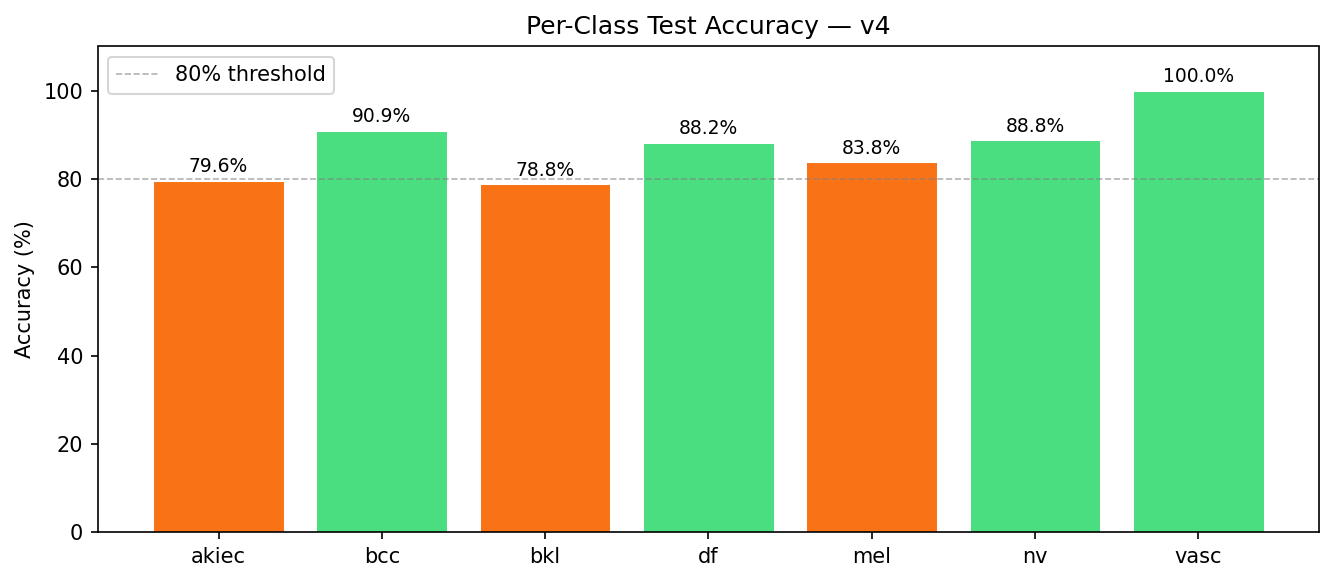


Per-class accuracy:
  akiec :  79.6%  ███████████████████████████████
  bcc   :  90.9%  ████████████████████████████████████
  bkl   :  78.8%  ███████████████████████████████
  df    :  88.2%  ███████████████████████████████████
  mel   :  83.8%  █████████████████████████████████
  nv    :  88.8%  ███████████████████████████████████
  vasc  : 100.0%  ████████████████████████████████████████


In [16]:
cm = confusion_matrix(test_labels, test_preds)
per_class_acc = cm.diagonal() / cm.sum(axis=1)

fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#ef4444' if a < 0.7 else '#f97316' if a < 0.85 else '#4ade80'
          for a in per_class_acc]
bars = ax.bar(CLASS_NAMES, per_class_acc * 100, color=colors, edgecolor='white', linewidth=0.5)
ax.set_ylim(0, 110)
ax.set_ylabel('Accuracy (%)')
ax.set_title('Per-Class Test Accuracy — v4')
ax.axhline(80, color='gray', linestyle='--', linewidth=0.8, alpha=0.6, label='80% threshold')
ax.legend()
for bar, acc in zip(bars, per_class_acc):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            f'{acc*100:.1f}%', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
bar_path = CONF_MAT_PATH.replace('confusion_matrix', 'per_class_acc')
plt.savefig(bar_path, dpi=150, bbox_inches='tight')
plt.close()
print(f'Bar chart saved → {bar_path}')

try:
    from IPython.display import Image as IPImage, display
    display(IPImage(bar_path))
except Exception:
    pass

print('\nPer-class accuracy:')
for cls, acc in zip(CLASS_NAMES, per_class_acc):
    bar = '█' * int(acc * 40)
    print(f'  {cls:6s}: {acc*100:5.1f}%  {bar}')

## STEP 16 — Summary & v1/v3/v4 Comparison

In [17]:
print('╔══════════════════════════════════════════════════════════════╗')
print('║         SKIN LESION CLASSIFIER v4 — FINAL SUMMARY            ║')
print('╠══════════════════════════════════════════════════════════════╣')
print(f'║  Architecture : Swin-B + Mask-Guided FPN + SE Block           ║')
print(f'║  Sampler      : Sqrt-WeightedRandomSampler                    ║')
print(f'║  MixUp        : alpha={MIXUP_ALPHA}, prob={MIXUP_PROB}                          ║')
print(f'║  Dataset      : HAM10000 ({len(train_df)+len(val_df)+len(test_df)} images)                     ║')
print(f'║  Split        : {len(train_df)} / {len(val_df)} / {len(test_df)}                         ║')
print(f'║  Test Loss    : {test_loss:.4f}                                     ║')
print(f'║  Test Accuracy: {test_acc:.4f}  ({test_acc*100:.1f}%)                          ║')
print(f'║  Test Macro F1: {test_f1:.4f}                                     ║')
print('╠══════════════════════════════════════════════════════════════╣')
print('║  COMPARISON (Macro F1 — higher is better)                     ║')
print('║  v1 (baseline, no sampler)       : 0.7886  ← previous best    ║')
print('║  v2 (sampler 1/n + MixUp 0.5)   : 0.5656  ← NV collapsed      ║')
print('║  v3 (sampler 1/n + MixUp 0.3)   : 0.7186  ← partial recovery  ║')
print(f'║  v4 (mask-guided + SE + sqrt)    : {test_f1:.4f}  ← current         ║')
print('╚══════════════════════════════════════════════════════════════╝')

╔══════════════════════════════════════════════════════════════╗
║         SKIN LESION CLASSIFIER v4 — FINAL SUMMARY            ║
╠══════════════════════════════════════════════════════════════╣
║  Architecture : Swin-B + Mask-Guided FPN + SE Block           ║
║  Sampler      : Sqrt-WeightedRandomSampler                    ║
║  MixUp        : alpha=0.4, prob=0.3                          ║
║  Dataset      : HAM10000 (10015 images)                     ║
║  Split        : 7010 / 1502 / 1503                         ║
║  Test Loss    : 1.6644                                     ║
║  Test Accuracy: 0.8709  (87.1%)                          ║
║  Test Macro F1: 0.7587                                     ║
╠══════════════════════════════════════════════════════════════╣
║  COMPARISON (Macro F1 — higher is better)                     ║
║  v1 (baseline, no sampler)       : 0.7886  ← previous best    ║
║  v2 (sampler 1/n + MixUp 0.5)   : 0.5656  ← NV collapsed      ║
║  v3 (sampler 1/n + MixUp 0.3)

## STEP 17 — XAI Setup & Sample Collection

In [18]:
import cv2
from pytorch_grad_cam import GradCAM, GradCAMPlusPlus
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from lime import lime_image
from skimage.segmentation import mark_boundaries

print(f'XAI output directory: {XAI_DIR}')

ckpt = torch.load(MODEL_SAVE_PATH, map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()
print(f'Model loaded for XAI. Best Val F1: {ckpt["best_val_f1"]:.4f}')

SAMPLES_PER_CLASS = 2

inv_normalize = __import__('torchvision').transforms.Normalize(
    mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
    std=[1/0.229, 1/0.224, 1/0.225]
)

def tensor_to_rgb(tensor):
    img = inv_normalize(tensor.cpu()).clamp(0, 1)
    return img.permute(1, 2, 0).numpy().astype('float32')

xai_samples = {i: [] for i in range(NUM_CLASSES)}

with torch.no_grad():
    for imgs, masks, labels in test_loader:
        imgs_dev  = imgs.to(DEVICE)
        masks_dev = masks.to(DEVICE)
        preds     = model(imgs_dev, masks_dev).argmax(dim=1).cpu()
        for img, msk, lbl, pred in zip(imgs, masks, labels, preds):
            c = lbl.item()
            if len(xai_samples[c]) < SAMPLES_PER_CLASS:
                xai_samples[c].append((img, msk, c, pred.item()))
        if all(len(v) >= SAMPLES_PER_CLASS for v in xai_samples.values()):
            break

print(f'Collected {sum(len(v) for v in xai_samples.values())} samples.')
for i, cls in enumerate(CLASS_NAMES):
    print(f'  {cls:6s}: {len(xai_samples[i])} sample(s)')

XAI output directory: D:\MULTIMODAL CLASSIFICATION V4\outputs\classifier_v4\xai_outputs
Model loaded for XAI. Best Val F1: 0.7784
Collected 14 samples.
  akiec : 2 sample(s)
  bcc   : 2 sample(s)
  bkl   : 2 sample(s)
  df    : 2 sample(s)
  mel   : 2 sample(s)
  nv    : 2 sample(s)
  vasc  : 2 sample(s)


## STEP 18 — Grad-CAM & Grad-CAM++

Applied on the last FPN smooth conv (P3 level).
The mask-guided model should show tighter heatmaps inside the lesion boundary compared to v1/v3.

Running Grad-CAM...
  Saved: D:\MULTIMODAL CLASSIFICATION V4\outputs\classifier_v4\xai_outputs\gradcam_akiec.png
  Saved: D:\MULTIMODAL CLASSIFICATION V4\outputs\classifier_v4\xai_outputs\gradcam_bcc.png
  Saved: D:\MULTIMODAL CLASSIFICATION V4\outputs\classifier_v4\xai_outputs\gradcam_bkl.png
  Saved: D:\MULTIMODAL CLASSIFICATION V4\outputs\classifier_v4\xai_outputs\gradcam_df.png
  Saved: D:\MULTIMODAL CLASSIFICATION V4\outputs\classifier_v4\xai_outputs\gradcam_mel.png
  Saved: D:\MULTIMODAL CLASSIFICATION V4\outputs\classifier_v4\xai_outputs\gradcam_nv.png
  Saved: D:\MULTIMODAL CLASSIFICATION V4\outputs\classifier_v4\xai_outputs\gradcam_vasc.png

Running Grad-CAM++...
  Saved: D:\MULTIMODAL CLASSIFICATION V4\outputs\classifier_v4\xai_outputs\gradcampp_akiec.png
  Saved: D:\MULTIMODAL CLASSIFICATION V4\outputs\classifier_v4\xai_outputs\gradcampp_bcc.png
  Saved: D:\MULTIMODAL CLASSIFICATION V4\outputs\classifier_v4\xai_outputs\gradcampp_bkl.png
  Saved: D:\MULTIMODAL CLASSIFICATION 

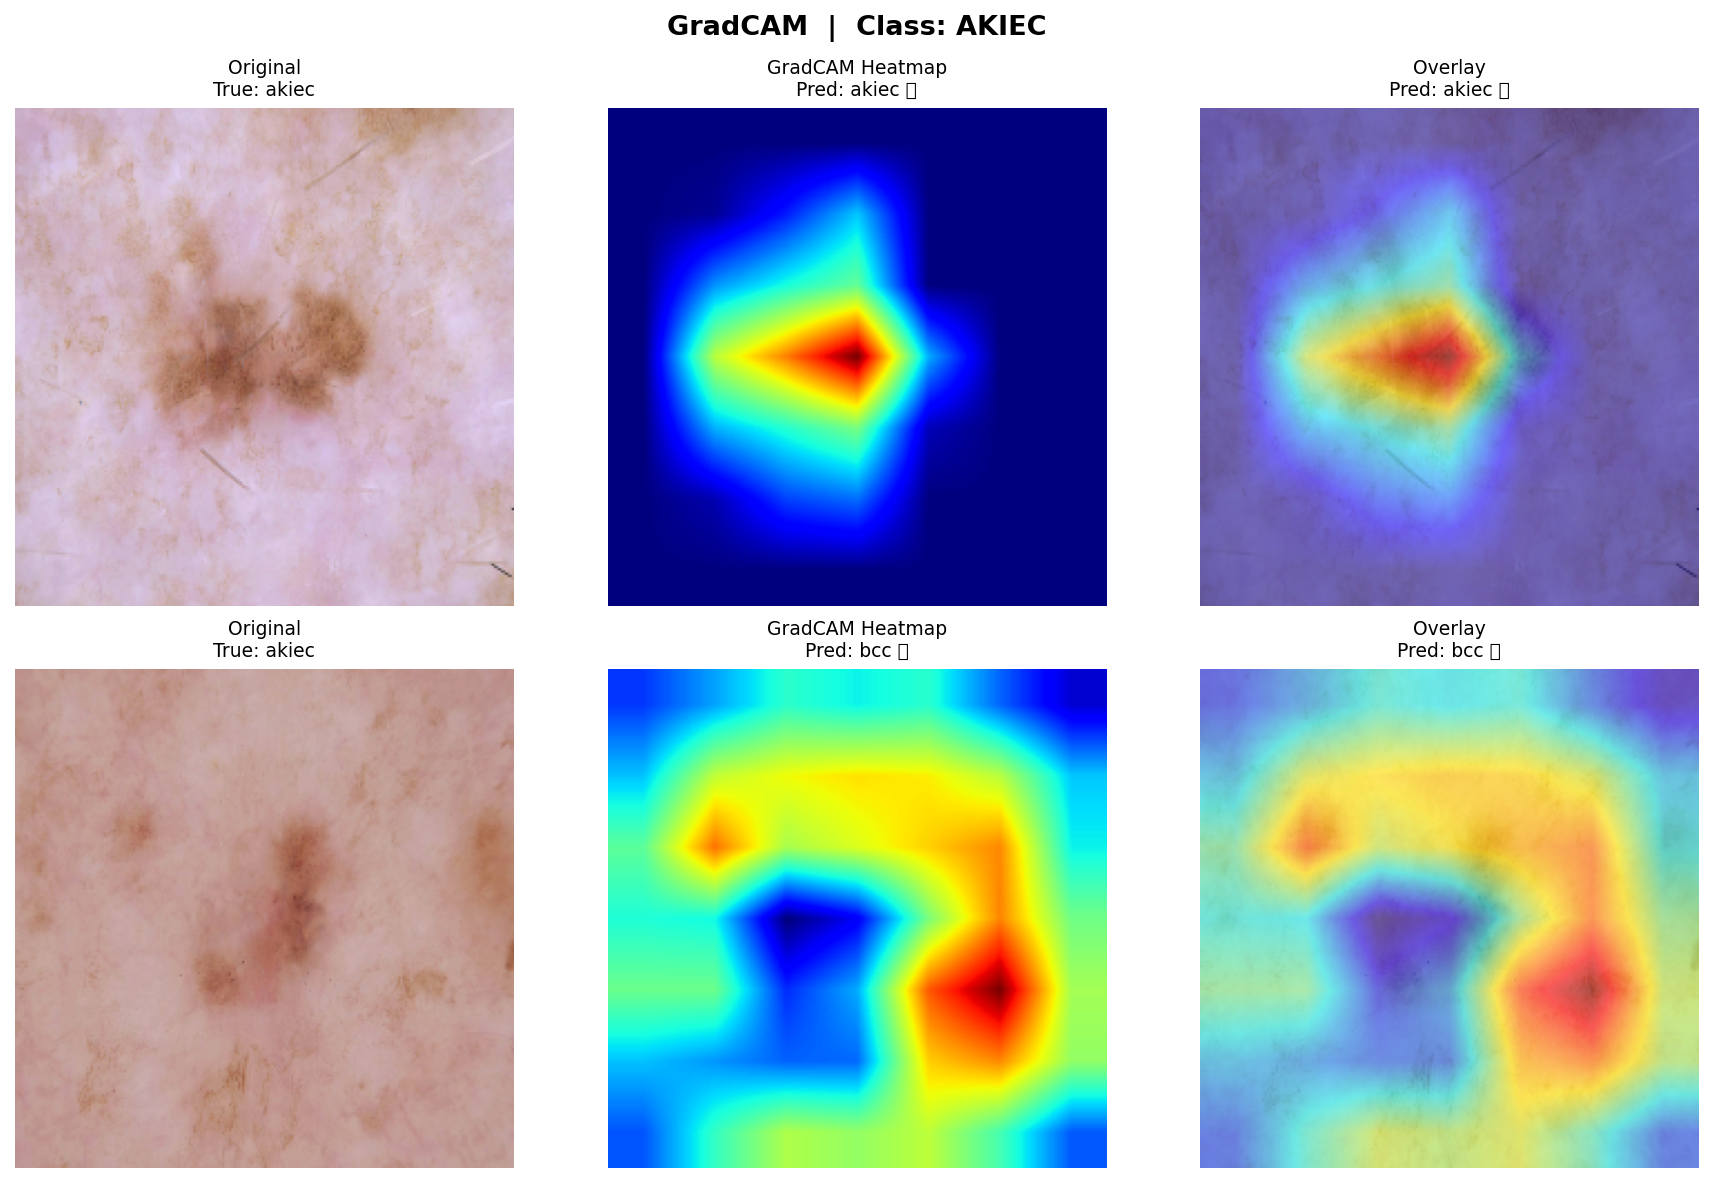

In [19]:
target_layers = [model.fpn.smooth_convs[-1][0]]

# Grad-CAM wrapper: model.forward() needs mask — we use the stored mask per sample
class MaskedModelWrapper(nn.Module):
    """Thin wrapper so grad-cam library can call forward(x) with the mask baked in."""
    def __init__(self, model, mask):
        super().__init__()
        self.model = model
        self.mask  = mask
    def forward(self, x):
        return self.model(x, self.mask)


def run_gradcam(sample_dict, method_class, method_name, save_dir):
    for class_idx, samples in sample_dict.items():
        if not samples:
            continue
        cls_name  = CLASS_NAMES[class_idx]
        n         = len(samples)
        fig, axes = plt.subplots(n, 3, figsize=(12, 4 * n))
        if n == 1:
            axes = [axes]
        fig.suptitle(f'{method_name}  |  Class: {cls_name.upper()}', fontsize=13, fontweight='bold')

        for row, (tensor, mask_tensor, true_lbl, pred_lbl) in enumerate(samples):
            rgb_img  = tensor_to_rgb(tensor)
            input_t  = tensor.unsqueeze(0).to(DEVICE)
            mask_t   = mask_tensor.unsqueeze(0).to(DEVICE)

            wrapped  = MaskedModelWrapper(model, mask_t)
            cam_eng  = method_class(model=wrapped, target_layers=[wrapped.model.fpn.smooth_convs[-1][0]])
            targets  = [ClassifierOutputTarget(pred_lbl)]
            g_cam    = cam_eng(input_tensor=input_t, targets=targets)[0]
            overlay  = show_cam_on_image(rgb_img, g_cam, use_rgb=True)
            correct  = '✅' if true_lbl == pred_lbl else '❌'
            pred_name= CLASS_NAMES[pred_lbl]

            axes[row][0].imshow(rgb_img)
            axes[row][0].set_title(f'Original\nTrue: {cls_name}', fontsize=9); axes[row][0].axis('off')
            axes[row][1].imshow(g_cam, cmap='jet')
            axes[row][1].set_title(f'{method_name} Heatmap\nPred: {pred_name} {correct}', fontsize=9); axes[row][1].axis('off')
            axes[row][2].imshow(overlay)
            axes[row][2].set_title(f'Overlay\nPred: {pred_name} {correct}', fontsize=9); axes[row][2].axis('off')

        plt.tight_layout()
        save_path = os.path.join(save_dir, f'{method_name.lower().replace("++","pp")}_{cls_name}.png')
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.close()
        print(f'  Saved: {save_path}')


print('Running Grad-CAM...')
run_gradcam(xai_samples, GradCAM,          'GradCAM',   XAI_DIR)
print('\nRunning Grad-CAM++...')
run_gradcam(xai_samples, GradCAMPlusPlus,  'GradCAM++', XAI_DIR)
print('\nGrad-CAM & Grad-CAM++ complete.')

try:
    from IPython.display import Image as IPImage, display
    p = os.path.join(XAI_DIR, f'gradcam_{CLASS_NAMES[0]}.png')
    if os.path.exists(p): display(IPImage(p))
except Exception:
    pass

## STEP 19 — Occlusion Sensitivity Maps

In [20]:
def occlusion_sensitivity(model, input_tensor, mask_tensor, target_class,
                          patch_size=28, stride=14, device=DEVICE):
    model.eval()
    C, H, W         = input_tensor.shape
    sensitivity_map = np.zeros((H, W), dtype='float32')
    count_map       = np.zeros((H, W), dtype='float32')

    mask_t = mask_tensor.unsqueeze(0).to(device)

    with torch.no_grad():
        base_prob = F.softmax(
            model(input_tensor.unsqueeze(0).to(device), mask_t), dim=1
        )[0, target_class].item()

    for y in range(0, H - patch_size + 1, stride):
        for x in range(0, W - patch_size + 1, stride):
            occ = input_tensor.clone()
            occ[:, y:y+patch_size, x:x+patch_size] = 0.5
            with torch.no_grad():
                prob = F.softmax(model(occ.unsqueeze(0).to(device), mask_t), dim=1)[0, target_class].item()
            drop = base_prob - prob
            sensitivity_map[y:y+patch_size, x:x+patch_size] += drop
            count_map[y:y+patch_size, x:x+patch_size]       += 1

    sensitivity_map /= np.maximum(count_map, 1)
    s_min, s_max = sensitivity_map.min(), sensitivity_map.max()
    if s_max > s_min:
        sensitivity_map = (sensitivity_map - s_min) / (s_max - s_min)
    return sensitivity_map


print('Running Occlusion Sensitivity Maps (~3-5 min)...')

for class_idx, samples in xai_samples.items():
    if not samples:
        continue
    cls_name  = CLASS_NAMES[class_idx]
    n         = len(samples)
    fig, axes = plt.subplots(n, 3, figsize=(12, 4 * n))
    if n == 1:
        axes = [axes]
    fig.suptitle(f'Occlusion Sensitivity  |  Class: {cls_name.upper()}', fontsize=13, fontweight='bold')

    for row, (tensor, mask_tensor, true_lbl, pred_lbl) in enumerate(samples):
        rgb_img         = tensor_to_rgb(tensor)
        sens_map        = occlusion_sensitivity(model, tensor, mask_tensor, pred_lbl)
        heatmap_colored = cv2.applyColorMap((sens_map * 255).astype('uint8'), cv2.COLORMAP_JET)
        heatmap_rgb     = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB) / 255.0
        overlay         = (0.5 * rgb_img + 0.5 * heatmap_rgb).clip(0, 1)
        correct         = '✅' if true_lbl == pred_lbl else '❌'
        pred_name       = CLASS_NAMES[pred_lbl]

        axes[row][0].imshow(rgb_img)
        axes[row][0].set_title(f'Original\nTrue: {cls_name}', fontsize=9); axes[row][0].axis('off')
        axes[row][1].imshow(sens_map, cmap='hot')
        axes[row][1].set_title('Sensitivity\nBright = Important', fontsize=9); axes[row][1].axis('off')
        axes[row][2].imshow(overlay)
        axes[row][2].set_title(f'Overlay\nPred: {pred_name} {correct}', fontsize=9); axes[row][2].axis('off')

    plt.tight_layout()
    save_path = os.path.join(XAI_DIR, f'occlusion_{cls_name}.png')
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.close()
    print(f'  {cls_name}: saved → {save_path}')

print('\nOcclusion Sensitivity complete.')

Running Occlusion Sensitivity Maps (~3-5 min)...
  akiec: saved → D:\MULTIMODAL CLASSIFICATION V4\outputs\classifier_v4\xai_outputs\occlusion_akiec.png
  bcc: saved → D:\MULTIMODAL CLASSIFICATION V4\outputs\classifier_v4\xai_outputs\occlusion_bcc.png
  bkl: saved → D:\MULTIMODAL CLASSIFICATION V4\outputs\classifier_v4\xai_outputs\occlusion_bkl.png
  df: saved → D:\MULTIMODAL CLASSIFICATION V4\outputs\classifier_v4\xai_outputs\occlusion_df.png
  mel: saved → D:\MULTIMODAL CLASSIFICATION V4\outputs\classifier_v4\xai_outputs\occlusion_mel.png
  nv: saved → D:\MULTIMODAL CLASSIFICATION V4\outputs\classifier_v4\xai_outputs\occlusion_nv.png
  vasc: saved → D:\MULTIMODAL CLASSIFICATION V4\outputs\classifier_v4\xai_outputs\occlusion_vasc.png

Occlusion Sensitivity complete.


## STEP 20 — LIME Explanations

In [21]:
def lime_predict_fn_v4(images_np, fixed_mask):
    """LIME predict function — uses the same mask for all perturbations."""
    mean  = torch.tensor([0.485, 0.456, 0.406])
    std   = torch.tensor([0.229, 0.224, 0.225])
    batch = []
    for img in images_np:
        t = torch.from_numpy(img).float() / 255.0
        t = (t - mean) / std
        batch.append(t.permute(2, 0, 1))
    batch    = torch.stack(batch).to(DEVICE)
    mask_rep = fixed_mask.unsqueeze(0).expand(batch.size(0), -1, -1, -1).to(DEVICE)
    model.eval()
    with torch.no_grad():
        probs = F.softmax(model(batch, mask_rep), dim=1)
    return probs.cpu().numpy()


explainer = lime_image.LimeImageExplainer()
print('Running LIME explanations (~4-6 min)...')

for class_idx, samples in xai_samples.items():
    if not samples:
        continue
    cls_name  = CLASS_NAMES[class_idx]
    n         = len(samples)
    fig, axes = plt.subplots(n, 3, figsize=(12, 4 * n))
    if n == 1:
        axes = [axes]
    fig.suptitle(f'LIME Explanation  |  Class: {cls_name.upper()}', fontsize=13, fontweight='bold')

    for row, (tensor, mask_tensor, true_lbl, pred_lbl) in enumerate(samples):
        rgb_img  = tensor_to_rgb(tensor)
        rgb_uint = (rgb_img * 255).astype('uint8')

        predict_fn = lambda imgs: lime_predict_fn_v4(imgs, mask_tensor)

        explanation = explainer.explain_instance(
            rgb_uint, predict_fn,
            top_labels=NUM_CLASSES, hide_color=0,
            num_samples=1000, random_seed=42
        )
        available_labels = list(explanation.local_exp.keys())
        label_to_use     = pred_lbl if pred_lbl in available_labels else available_labels[0]

        temp_img, mask = explanation.get_image_and_mask(
            label_to_use, positive_only=False, num_features=8, hide_rest=False
        )
        temp_pos, mask_pos = explanation.get_image_and_mask(
            label_to_use, positive_only=True, num_features=8, hide_rest=True
        )
        correct   = '✅' if true_lbl == pred_lbl else '❌'
        pred_name = CLASS_NAMES[pred_lbl]

        axes[row][0].imshow(rgb_img)
        axes[row][0].set_title(f'Original\nTrue: {cls_name}', fontsize=9); axes[row][0].axis('off')
        axes[row][1].imshow(mark_boundaries(temp_img / 255.0, mask))
        axes[row][1].set_title(f'LIME: Green=For / Red=Against\nPred: {pred_name} {correct}', fontsize=9); axes[row][1].axis('off')
        axes[row][2].imshow(mark_boundaries(temp_pos / 255.0, mask_pos))
        axes[row][2].set_title(f'LIME: Positive Evidence Only\nPred: {pred_name} {correct}', fontsize=9); axes[row][2].axis('off')

    plt.tight_layout()
    save_path = os.path.join(XAI_DIR, f'lime_{cls_name}.png')
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.close()
    print(f'  {cls_name}: saved → {save_path}')

print('\nLIME complete.')

Running LIME explanations (~4-6 min)...


  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  akiec: saved → D:\MULTIMODAL CLASSIFICATION V4\outputs\classifier_v4\xai_outputs\lime_akiec.png


  0%|          | 0/1000 [00:00<?, ?it/s]

...

  0%|          | 0/1000 [00:00<?, ?it/s]

  nv: saved → D:\MULTIMODAL CLASSIFICATION V4\outputs\classifier_v4\xai_outputs\lime_nv.png


  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  vasc: saved → D:\MULTIMODAL CLASSIFICATION V4\outputs\classifier_v4\xai_outputs\lime_vasc.png

LIME complete.


## STEP 21 — XAI Summary Grid (All 4 Methods Side by Side)

Generating XAI Summary Grids...


  0%|          | 0/1000 [00:00<?, ?it/s]

  akiec: saved → D:\MULTIMODAL CLASSIFICATION V4\outputs\classifier_v4\xai_outputs\xai_summary_akiec.png


  0%|          | 0/1000 [00:00<?, ?it/s]

  bcc: saved → D:\MULTIMODAL CLASSIFICATION V4\outputs\classifier_v4\xai_outputs\xai_summary_bcc.png


...

  mel: saved → D:\MULTIMODAL CLASSIFICATION V4\outputs\classifier_v4\xai_outputs\xai_summary_mel.png


  0%|          | 0/1000 [00:00<?, ?it/s]

  nv: saved → D:\MULTIMODAL CLASSIFICATION V4\outputs\classifier_v4\xai_outputs\xai_summary_nv.png


  0%|          | 0/1000 [00:00<?, ?it/s]

  vasc: saved → D:\MULTIMODAL CLASSIFICATION V4\outputs\classifier_v4\xai_outputs\xai_summary_vasc.png

All XAI Summary Grids saved.


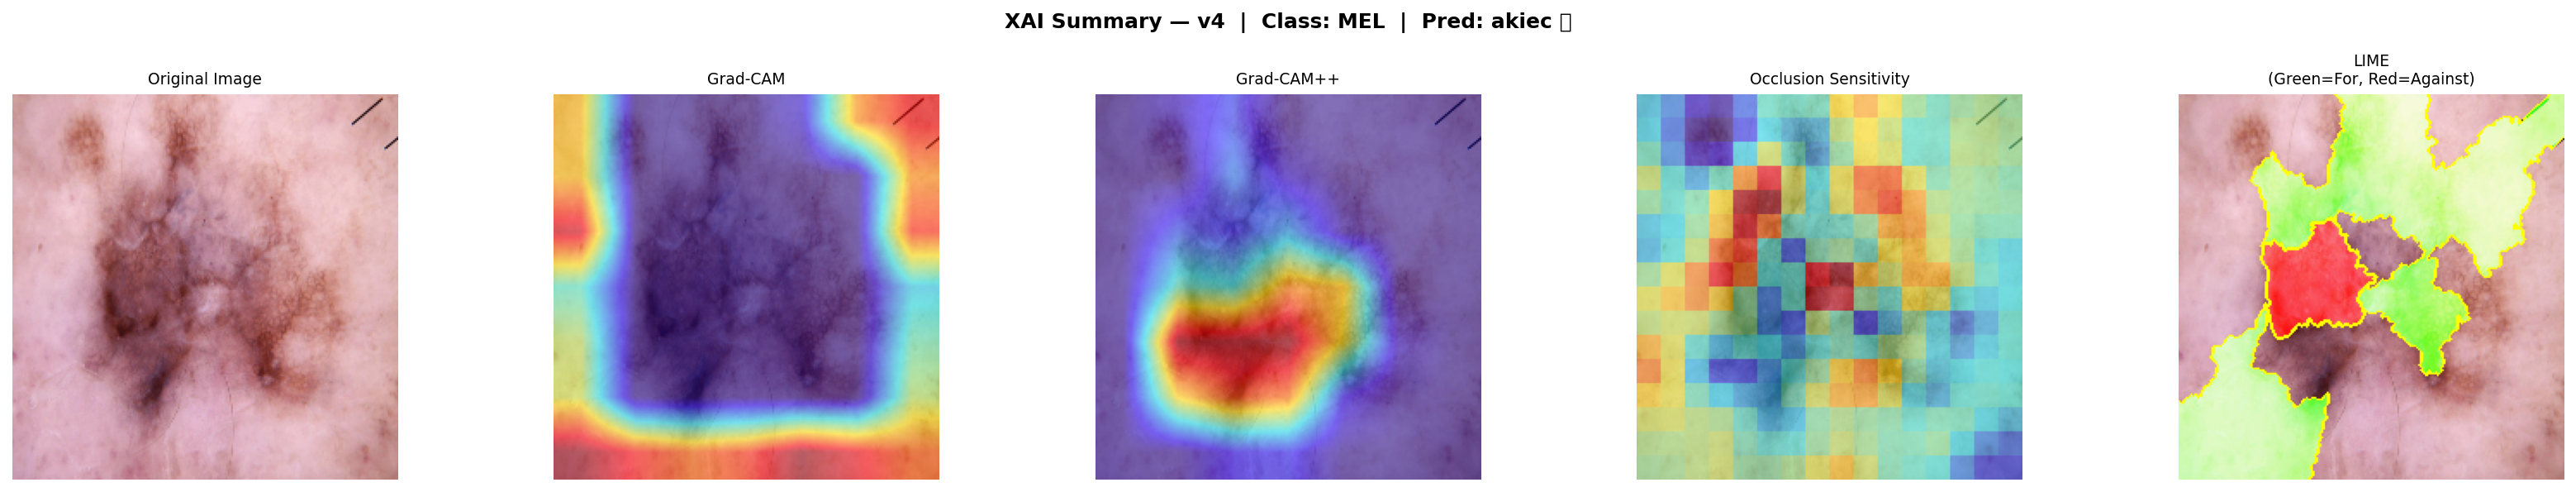


  XAI PIPELINE COMPLETE
  All outputs saved to: D:\MULTIMODAL CLASSIFICATION V4\outputs\classifier_v4\xai_outputs
  Files generated:
    gradcam_akiec.png
    gradcam_bcc.png
    gradcam_bkl.png
    gradcam_df.png
    gradcam_mel.png
    gradcam_nv.png
    gradcam_vasc.png
    gradcampp_akiec.png
    gradcampp_bcc.png
    gradcampp_bkl.png
    gradcampp_df.png
    gradcampp_mel.png
    gradcampp_nv.png
    gradcampp_vasc.png
    lime_akiec.png
    lime_bcc.png
    lime_bkl.png
    lime_df.png
    lime_mel.png
    lime_nv.png
    lime_vasc.png
    occlusion_akiec.png
    occlusion_bcc.png
    occlusion_bkl.png
    occlusion_df.png
    occlusion_mel.png
    occlusion_nv.png
    occlusion_vasc.png
    xai_summary_akiec.png
    xai_summary_bcc.png
    xai_summary_bkl.png
    xai_summary_df.png
    xai_summary_mel.png
    xai_summary_nv.png
    xai_summary_vasc.png


In [22]:
print('Generating XAI Summary Grids...')

for class_idx, samples in xai_samples.items():
    if not samples:
        continue

    cls_name                      = CLASS_NAMES[class_idx]
    tensor, mask_tensor, true_lbl, pred_lbl = samples[0]
    rgb_img   = tensor_to_rgb(tensor)
    input_t   = tensor.unsqueeze(0).to(DEVICE)
    mask_t    = mask_tensor.unsqueeze(0).to(DEVICE)
    rgb_uint  = (rgb_img * 255).astype('uint8')
    correct   = '✅' if true_lbl == pred_lbl else '❌'
    pred_name = CLASS_NAMES[pred_lbl]
    targets   = [ClassifierOutputTarget(pred_lbl)]

    # 1. Grad-CAM
    wrapped  = MaskedModelWrapper(model, mask_t)
    cam_eng  = GradCAM(model=wrapped, target_layers=[wrapped.model.fpn.smooth_convs[-1][0]])
    gcam_map = cam_eng(input_tensor=input_t, targets=targets)[0]
    gcam_overlay = show_cam_on_image(rgb_img, gcam_map, use_rgb=True)

    # 2. Grad-CAM++
    cam_eng2    = GradCAMPlusPlus(model=wrapped, target_layers=[wrapped.model.fpn.smooth_convs[-1][0]])
    gcampp_map  = cam_eng2(input_tensor=input_t, targets=targets)[0]
    gcampp_overlay = show_cam_on_image(rgb_img, gcampp_map, use_rgb=True)

    # 3. Occlusion
    sens_map        = occlusion_sensitivity(model, tensor, mask_tensor, pred_lbl)
    heatmap_colored = cv2.applyColorMap((sens_map * 255).astype('uint8'), cv2.COLORMAP_JET)
    occ_overlay     = (0.5 * rgb_img +
                       0.5 * cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB) / 255.0).clip(0, 1)

    # 4. LIME
    predict_fn = lambda imgs: lime_predict_fn_v4(imgs, mask_tensor)
    lime_exp   = explainer.explain_instance(
        rgb_uint, predict_fn, top_labels=NUM_CLASSES,
        hide_color=0, num_samples=1000, random_seed=42
    )
    available_labels = list(lime_exp.local_exp.keys())
    label_to_use     = pred_lbl if pred_lbl in available_labels else available_labels[0]
    lime_img, lime_mask = lime_exp.get_image_and_mask(
        label_to_use, positive_only=False, num_features=8, hide_rest=False
    )
    lime_overlay = mark_boundaries(lime_img / 255.0, lime_mask)

    fig, axes = plt.subplots(1, 5, figsize=(22, 4))
    fig.suptitle(
        f'XAI Summary — v4  |  Class: {cls_name.upper()}  |  Pred: {pred_name} {correct}',
        fontsize=12, fontweight='bold'
    )
    for ax, (img, title) in zip(axes, [
        (rgb_img,        'Original Image'),
        (gcam_overlay,   'Grad-CAM'),
        (gcampp_overlay, 'Grad-CAM++'),
        (occ_overlay,    'Occlusion Sensitivity'),
        (lime_overlay,   'LIME\n(Green=For, Red=Against)'),
    ]):
        ax.imshow(img); ax.set_title(title, fontsize=9); ax.axis('off')

    plt.tight_layout()
    save_path = os.path.join(XAI_DIR, f'xai_summary_{cls_name}.png')
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.close()
    print(f'  {cls_name}: saved → {save_path}')

print('\nAll XAI Summary Grids saved.')
try:
    from IPython.display import Image as IPImage, display
    ex_path = os.path.join(XAI_DIR, f'xai_summary_{CLASS_NAMES[4]}.png')
    if os.path.exists(ex_path):
        display(IPImage(ex_path))
except Exception:
    pass

print('\n' + '=' * 55)
print('  XAI PIPELINE COMPLETE')
print('=' * 55)
print(f'  All outputs saved to: {XAI_DIR}')
print('  Files generated:')
for f in sorted(os.listdir(XAI_DIR)):
    print(f'    {f}')